In [49]:
# Import relevant stuff for the project

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

### <u> Lab 01: Problem Formulation, Requirement Analysis, and Source Identification </u>

Link to Presentation Slides: 

### **ASK** : Problem Formulation

#### *"How do different learning methods and lifestyle factors influence students’ exam scores, and what actionable study strategies can be recommended to improve scores?"*

> *Clearly state the data science hypothesis / the analytical goal you pursue in your project. From your description, it should be clear which question you address, what type of analysis is needed, and what quality metric is targeted.*


Students adopt different learning methods and study habits, and increasingly make use of AI tools to support their learning, which may influence their academic performance. The goal of this project is to examine how traditional learning behaviors, such as study hours, class attendance, and sleep patterns, together with AI-assisted learning practices are related to exam scores and overall academic outcomes. The main question addressed is whether certain learning approaches, including the way AI tools are used, are associated with better academic performance.

This project applies descriptive and prescriptive analysis using exploratory data analysis, correlation analysis, and group comparisons. Rather than building predictive models, the focus is on understanding relationships between learning behaviors, AI usage, and academic outcomes, and interpreting their practical implications. The findings are used to derive data-driven recommendations on effective and responsible learning strategies that may help students improve their academic performance.

### **PREPARE** : Data Source Identification and Exploration

#### A. Requirement Analysis

>*Make a brief requirements analysis for the data and data sources that you require to reach your goal.*

To address the problem, we require student-level data that captures academic outcomes together with learning-related factors, including both traditional study behaviors and the use of AI-assisted learning tools. The data must include exam or final scores, along with variables describing study habits (such as study hours, study method, and class attendance), lifestyle factors (such as sleep duration), and access to learning resources. In addition, data on students’ AI usage, such as frequency, duration, and purpose of use—is required to analyze how AI-assisted learning relates to academic performance. Basic demographic information, including age and gender, is included to support subgroup comparisons.

It is desirable to have data covering a diverse group of students with different study habits and levels of AI usage to enable meaningful comparisons across learning approaches. Since the objective is to analyze overall academic performance rather than short-term behavior, one aggregated record per student is sufficient. Fine-grained temporal data is not required, as the analysis focuses on identifying general relationships and patterns that can inform practical recommendations on study strategies.

### B. Source Identification

> *List the sources you will report on for Deliverable 1 and link them to where you found them. In selecting which datasets you want to report on for exploration, take note of the following: <br> (1) The subsequent data preparation and analysis should rely on at least 3 datasets; <br> (2) the discussion concerning exploration needs to feature arguments for why datasets were selected and why others were not.*

In the following, we outline several sources we considered and explored and justify the final source selection. All the three datasets are obtained from [kaggle](https://www.kaggle.com/).

**1. Traditional Learning Behaviour**
  * [Traditional Learning Behaviour (DS1) - ds1_study-habit.csv](https://www.kaggle.com/competitions/playground-series-s6e1/data)

  * This datasets will mainly gives information about the students learning behaviour. Some important features includes:
    * Study Hours, Class Attendance
    * Sleep hours, Sleep Quality
    * Internet Access, Facility Rating, etc
   
**2. Student's Lifestyle**
  * [Student's Lifestyle (DS2) - ds2_lifestyle.csv](https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance)

  * This datasets will mainly gives information about how students are doing their lifestyle outside of their academic stuff. Some important features includes:
    * Social Media Hours, Netflix Hours
    * Part Time Job, Extracurricular Participation
    * Diet Quality, Exercise Frequency
    * Parents Education level
    * Internet Quality
    * Mental Health Rating, etc
   
**3. Usage of AI in their Study**
  * [Student's AI Usage (DS3) - ds3_ai-usage.csv](https://www.kaggle.com/datasets/ankushnarwade/ai-impact-on-student-performance)

  * This datasets will mainly gives information about how students are using AI to enhance their study. Some important features includes:
    * Usage of AI
    * Name of AI Tools Used
    * Percentage of AI Generated content
    * AI usage per week
    * AI ethics score, etc


### <u> Lab 02: Justified Source Selection and Data Preparation </u>

Link to Presentation Slides: 



> *In this section, describe, justify, and implement transoformation and profiling tasks to prepare the data you have selected for later analysis. Structure the section as follows:*
*   *Overview: provides a summary of the transformations performed, reffering to the specific types of operations discussed in class. Should include a visualization of the transformation pipeline.*
*   *For each individual operation (task), briefly describe what it does using terms defined in class, why you perform it, and implement it.*





### **PREPARE** : Data Preparation

To ensure that the subsequent data analysis we will be executing is accurate and reliable, we conducted a rigorous data preparation process outlining the different stages of data preparation across all our datasets:
- ds1_main  
- ds2_lifestyle  
- ds3_ai-usage  
- ds3_social-media  
- ds4_digital-literacy  


### Assessing Structure of Datasets (Profiling)

Firstly, we wanted to examine the structure of all our datasets. We derived the following metadata through single-column profiling tasks:
- No. of rows & columns
- Variable types
- Memory usage
- Duplicates

We standardised column names to lowercase for consistency and to avoid any encoding errors.

These facilitates the integration of sources to get a harmonised schema.

In [ ]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = "datasets"  # change if needed

DATASETS = {
    "ds1_main": os.path.join(DATA_DIR, "ds1_main.csv"),
    "ds2_lifestyle": os.path.join(DATA_DIR, "ds2_lifestyle.csv"),
    "ds3_ai_usage": os.path.join(DATA_DIR, "ds3_ai-usage.csv"),
    "ds3_social_media": os.path.join(DATA_DIR, "ds3_social-media.csv"),
    "ds4_digital_literacy": os.path.join(DATA_DIR, "ds4_digital-literacy.csv"),
}

# -----------------------------
# Helpers
# -----------------------------
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Standardize column names to lowercase snake_case and strip whitespace."""
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^a-z0-9_]+", "", regex=True)
    )
    return df

def coerce_numeric_like(df: pd.DataFrame, min_numeric_ratio: float = 0.85) -> pd.DataFrame:
    """
    Convert object columns that are mostly numeric into numeric dtype.
    min_numeric_ratio: fraction of non-null values that must parse as numeric.
    """
    df = df.copy()
    for c in df.columns:
        if df[c].dtype == "object":
            s = df[c].astype(str).str.strip()
            # treat empty strings as NaN
            s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})
            parsed = pd.to_numeric(s, errors="coerce")
            non_null = s.notna().sum()
            if non_null > 0:
                ratio = parsed.notna().sum() / non_null
                if ratio >= min_numeric_ratio:
                    df[c] = parsed
    return df

def safe_read_csv(path: str) -> pd.DataFrame:
    """
    Robust CSV reader:
    - tries default comma
    - falls back to python engine if needed
    """
    # First attempt
    try:
        df = pd.read_csv(path)
        return df
    except Exception:
        pass

    # Second attempt with python engine
    try:
        df = pd.read_csv(path, engine="python")
        return df
    except Exception as e:
        raise RuntimeError(f"Failed to read {path}: {e}")

def basic_overview(df: pd.DataFrame) -> dict:
    """Return a dictionary of core dataset overview stats."""
    n_rows, n_cols = df.shape
    dtypes = df.dtypes.astype(str)
    type_counts = dtypes.value_counts().to_dict()
    mem_mb = df.memory_usage(deep=True).sum() / (1024**2)

    n_numeric = df.select_dtypes(include=[np.number]).shape[1]
    n_categorical = df.select_dtypes(include=["object", "category", "bool"]).shape[1]
    n_datetime = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).shape[1]

    return {
        "rows": n_rows,
        "cols": n_cols,
        "numeric_cols": n_numeric,
        "categorical_cols": n_categorical,
        "datetime_cols": n_datetime,
        "memory_mb": round(mem_mb, 2),
        "dtype_counts": type_counts,
    }

def missing_profile(df: pd.DataFrame) -> pd.DataFrame:
    """Missing value counts and percentages."""
    miss_cnt = df.isna().sum()
    miss_pct = (miss_cnt / len(df) * 100).round(2)
    out = pd.DataFrame({"missing_count": miss_cnt, "missing_pct": miss_pct})
    out = out.sort_values(["missing_pct", "missing_count"], ascending=False)
    return out

def duplicate_profile(df: pd.DataFrame) -> dict:
    """Duplicate rows and duplicate counts for likely ID columns."""
    dup_rows = int(df.duplicated().sum())

    # Heuristic: columns that look like IDs
    id_like = [c for c in df.columns if re.search(r"(?:^id$|_id$|^student_id$|^user_id$)", c)]
    id_dup_info = {}
    for c in id_like:
        if c in df.columns:
            # Only meaningful if not all missing
            non_null = df[c].notna().sum()
            if non_null > 0:
                id_dup_info[c] = int(df[c].duplicated().sum())
    return {"duplicate_rows": dup_rows, "id_like_duplicate_counts": id_dup_info, "id_like_cols": id_like}

def numeric_profile(df: pd.DataFrame) -> pd.DataFrame:
    """Descriptive stats for numeric columns + skewness."""
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] == 0:
        return pd.DataFrame()
    desc = num.describe().T
    desc["skew"] = num.skew(numeric_only=True)
    desc["kurtosis"] = num.kurtosis(numeric_only=True)
    return desc.sort_values("std", ascending=False)

def categorical_profile(df: pd.DataFrame, top_k: int = 10) -> dict:
    """
    For each categorical column, show:
    - unique count
    - top values (%)
    """
    cat = df.select_dtypes(include=["object", "category", "bool"])
    profiles = {}
    for c in cat.columns:
        vc = df[c].astype("object").value_counts(dropna=False)
        total = vc.sum()
        top = (vc.head(top_k) / total * 100).round(2)
        profiles[c] = {
            "unique_count": int(df[c].nunique(dropna=True)),
            "top_values_pct": top.to_frame("pct").reset_index().rename(columns={"index": c}),
        }
    return profiles

def correlation_plot(df: pd.DataFrame, title: str = "", max_cols: int = 20):
    """
    Correlation heatmap for numeric columns.
    Limits to max_cols to keep plots readable.
    """
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] < 2:
        print("Not enough numeric columns for correlation plot.")
        return

    # If too many numeric columns, pick those with highest variance (std)
    if num.shape[1] > max_cols:
        stds = num.std(numeric_only=True).sort_values(ascending=False)
        keep = stds.head(max_cols).index
        num = num[keep]

    corr = num.corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title(title or "Correlation heatmap")
    plt.tight_layout()
    plt.show()

def distribution_plots(df: pd.DataFrame, dataset_name: str, max_plots: int = 6):
    """
    Plot distributions for key numeric columns.
    - Picks up to max_plots numeric columns with highest variance
    """
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] == 0:
        print("No numeric columns to plot.")
        return

    stds = num.std(numeric_only=True).sort_values(ascending=False)
    cols = list(stds.head(max_plots).index)

    for c in cols:
        plt.figure(figsize=(7, 4))
        plt.hist(num[c].dropna(), bins=30)
        plt.title(f"{dataset_name}: Distribution of {c}")
        plt.xlabel(c)
        plt.ylabel("count")
        plt.tight_layout()
        plt.show()

def target_focus(df: pd.DataFrame, dataset_name: str, target_candidates=("exam_score", "final_score", "score")):
    """
    If a likely target variable exists, show extra profiling:
    - distribution
    - group means by key categoricals (if any)
    """
    target = None
    for t in target_candidates:
        if t in df.columns:
            target = t
            break
    if target is None:
        return

    print(f"\n🎯 Target-focused profiling for {dataset_name}: '{target}'")

    # Distribution
    plt.figure(figsize=(7, 4))
    plt.hist(df[target].dropna(), bins=30)
    plt.title(f"{dataset_name}: {target} distribution")
    plt.xlabel(target)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    # Group means for a few categoricals (top 3 by cardinality under threshold)
    cats = df.select_dtypes(include=["object", "category", "bool"])
    if cats.shape[1] == 0:
        return

    # Pick columns with reasonable cardinality
    good_cats = []
    for c in cats.columns:
        nuniq = df[c].nunique(dropna=True)
        if 2 <= nuniq <= 8:
            good_cats.append((c, nuniq))
    good_cats = sorted(good_cats, key=lambda x: x[1])[:3]

    for c, _ in good_cats:
        grp = df.groupby(c)[target].mean().sort_values(ascending=False)
        print(f"\nMean {target} by {c}:")
        display(grp)

# -----------------------------
# Main profiling runner
# -----------------------------
def profile_dataset(df: pd.DataFrame, name: str):
    print("\n" + "=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)

    # Overview
    ov = basic_overview(df)
    print("Overview:", ov)

    # Sample rows
    print("\nHead:")
    display(df.head(5))

    # Missing values
    miss = missing_profile(df)
    print("\nMissingness (top 15):")
    display(miss.head(15))

    # Duplicates
    dup = duplicate_profile(df)
    print("\nDuplicates:", dup)

    # Numeric profile
    num_prof = numeric_profile(df)
    if not num_prof.empty:
        print("\nNumeric profile (top 15 by std):")
        display(num_prof.head(15))
    else:
        print("\nNo numeric columns found for numeric profiling.")

    # Categorical profile (top values)
    cat_prof = categorical_profile(df, top_k=8)
    if len(cat_prof) > 0:
        print("\nCategorical profile (showing up to 6 columns):")
        shown = 0
        for c, info in cat_prof.items():
            print(f"\nColumn: {c} | unique_count={info['unique_count']}")
            display(info["top_values_pct"])
            shown += 1
            if shown >= 6:
                break
    else:
        print("\nNo categorical columns found for categorical profiling.")

    # Plots
    print("\nPlots: distributions (up to 6 numeric columns)")
    distribution_plots(df, dataset_name=name, max_plots=6)

    print("\nPlots: correlation heatmap (numeric columns)")
    correlation_plot(df, title=f"{name}: correlation heatmap", max_cols=20)

    # Target-focused profiling (if any)
    target_focus(df, dataset_name=name)

# ============================================================
# 1) Load all datasets
# ============================================================
dfs = {}
for name, path in DATASETS.items():
    print(f"Loading {name} from {path} ...")
    df = safe_read_csv(path)

    # Standardize columns & basic coercions
    df = standardize_columns(df)
    df = coerce_numeric_like(df, min_numeric_ratio=0.85)

    # Keep a copy
    dfs[name] = df

print("\nLoaded datasets:", list(dfs.keys()))

# ============================================================
# 2) Profile each dataset (Notebook-style)
# ============================================================
for name, df in dfs.items():
    profile_dataset(df, name)

# ============================================================
# 3) Cross-dataset schema comparison (optional but strong)
# ============================================================
print("\n" + "=" * 80)
print("CROSS-DATASET COMPARISON: shared columns + schema differences")
print("=" * 80)

all_cols = {name: set(df.columns) for name, df in dfs.items()}
shared = set.intersection(*all_cols.values())
print(f"\nShared columns across ALL 5 datasets ({len(shared)}):")
print(sorted(shared))

# Pairwise overlaps
pairs = []
names = list(dfs.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        a, b = names[i], names[j]
        inter = all_cols[a].intersection(all_cols[b])
        pairs.append((a, b, len(inter)))

pair_df = pd.DataFrame(pairs, columns=["dataset_a", "dataset_b", "shared_col_count"]).sort_values("shared_col_count", ascending=False)
print("\nPairwise shared column counts:")
display(pair_df)

# Dtype summary per dataset
dtype_summaries = []
for name, df in dfs.items():
    dtype_summaries.append(
        pd.DataFrame({"dataset": name, "column": df.columns, "dtype": df.dtypes.astype(str).values})
    )
dtype_summaries = pd.concat(dtype_summaries, ignore_index=True)
print("\nDtype summary (first 50 rows):")
display(dtype_summaries.head(50))

# Please ignore the section below

Loading ds1_main from datasets\ds1_main.csv ...
Loading ds2_lifestyle from datasets\ds2_lifestyle.csv ...
Loading ds3_ai_usage from datasets\ds3_ai-usage.csv ...
Loading ds3_social_media from datasets\ds3_social-media.csv ...
Loading ds4_digital_literacy from datasets\ds4_digital-literacy.csv ...


C:\Users\wayne\AppData\Local\Temp\ipykernel_14820\1247767163.py:69: DtypeWarning: Columns (8,9,10,21,22,23,75,104,106,107,108,117,118,240,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,281,282,283,284,285,286,287,288,289,290,291,292,294,296,299,308,309,315,316,317,324,393,395,396,397,398,409,410,411,414,421,422,426,427,437,441,445,449,453,457,461,465,469,473,477,485,497,501,505,509,513,517,521,529,533,537,541,545,557,561,565,569,573,577,581,585,597,605,609,613,617,641,645,653,657,661,665,669,673,677,681,685,689,693,697,701,705,709,713,717,721,725,729,733,737,741,745,749,753,757,761,765,769,773,777,781,785,789,793,797,801,805,809,813,821,829,833,837,841,845,849,896,898,899,900,901,903,904,907,908,909,917,918,919,920,921,922,923,924,925,926,927,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,958,960,962,964,966,968,970,972,974,976,978,980,982,984,986,988,990,992,994,996,998,1000,1002,1004,1006,1008,1010,1012,1286,1304) 


Loaded datasets: ['ds1_main', 'ds2_lifestyle', 'ds3_ai_usage', 'ds3_social_media', 'ds4_digital_literacy']

DATASET: ds1_main
Overview: {'rows': 8000, 'cols': 26, 'numeric_cols': 21, 'categorical_cols': 5, 'datetime_cols': 0, 'memory_mb': 3.33, 'dtype_counts': {'int64': 12, 'float64': 9, 'object': 5}}

Head:


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,29,56,5,29,40.9,98.8,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,14,65,1,60,87.2,89.3,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,82,8,5,98,77.1,50.8,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,74,106,10,67,86.4,52.1,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,83,7,10,40,69.4,40.7,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low



Missingness (top 15):


...


Column: ai_usage_purpose | unique_count=5


,ai_usage_purpose,pct
0,Exam Prep,17.10
1,NaN,16.83
2,Doubt Solving,16.78
3,Homework,16.65
4,Coding,16.44
5,Notes,16.21



Column: performance_category | unique_count=3


,performance_category,pct
0,Medium,58.81
1,Low,31.78
2,High,9.41



Plots: distributions (up to 6 numeric columns)


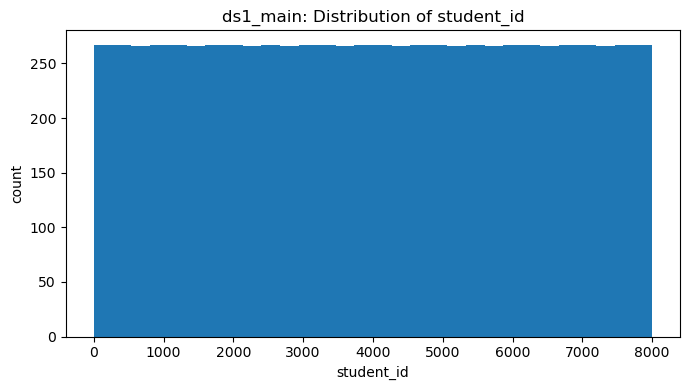

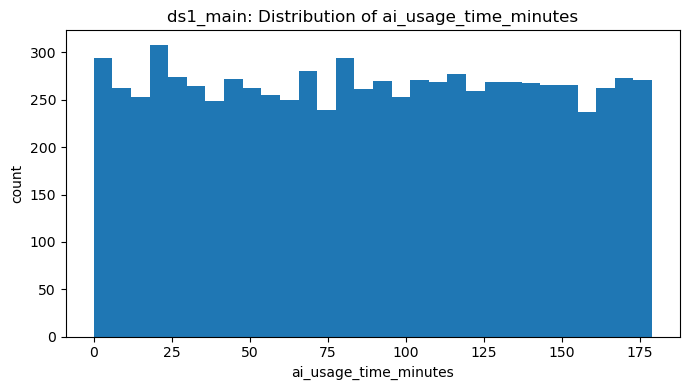

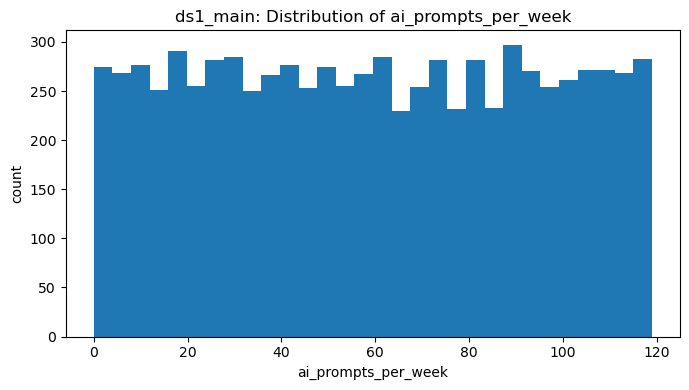

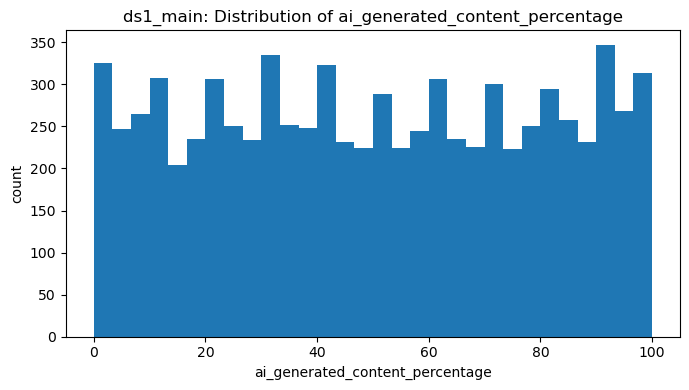

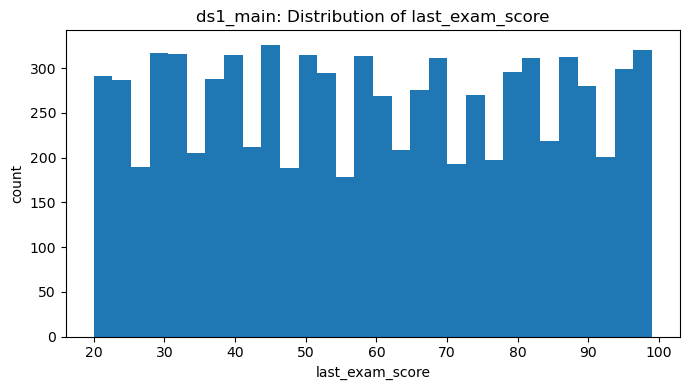

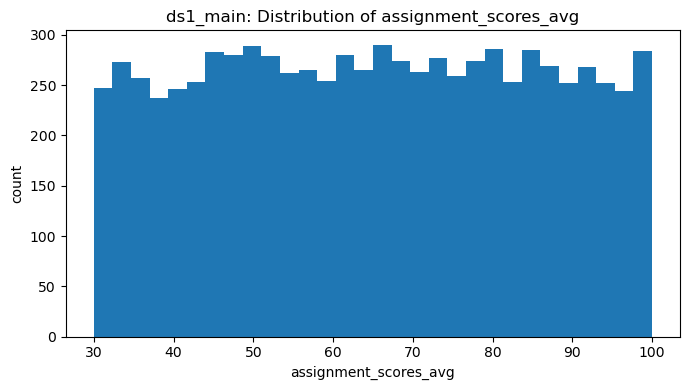


Plots: correlation heatmap (numeric columns)


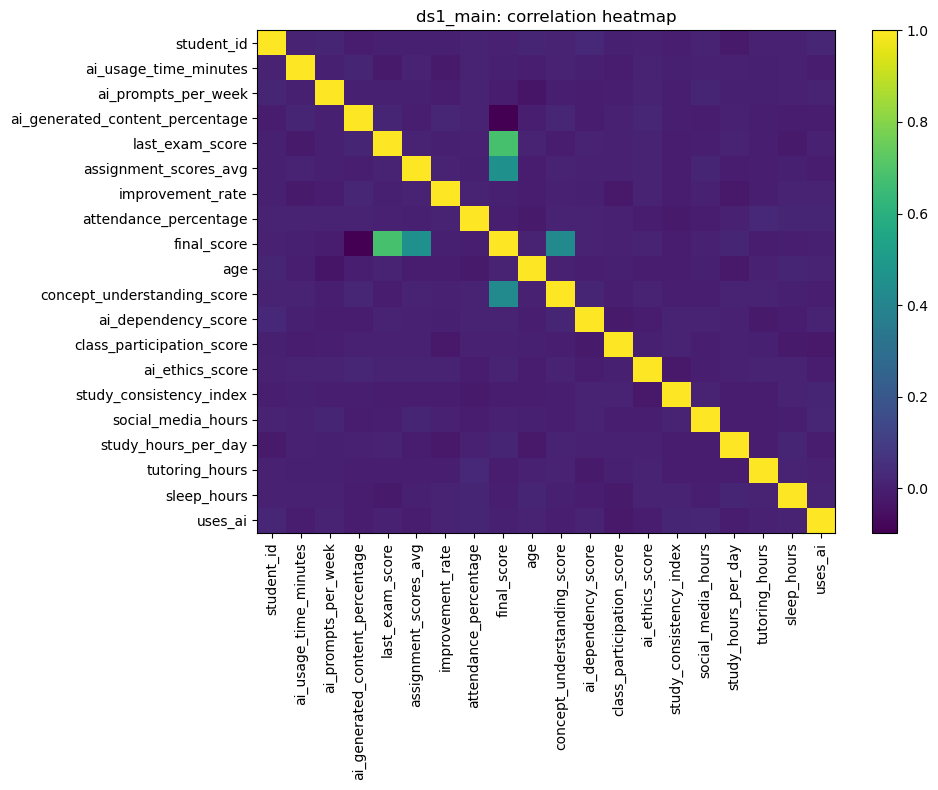


🎯 Target-focused profiling for ds1_main: 'final_score'


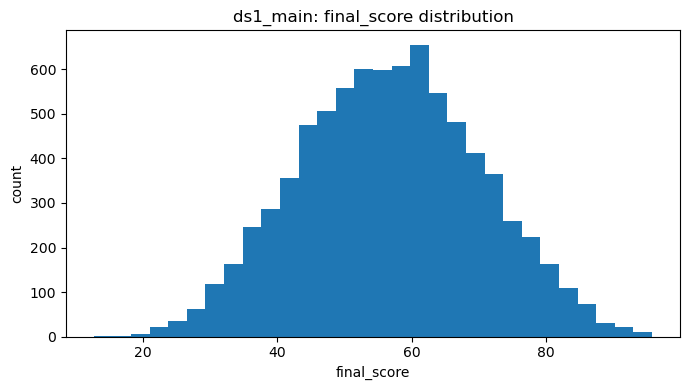


Mean final_score by gender:


gender
Male      56.846878
Female    56.840514
Other     55.939858
Name: final_score, dtype: float64


Mean final_score by performance_category:


performance_category
High      80.696547
Medium    61.240191
Low       41.540637
Name: final_score, dtype: float64


Mean final_score by ai_tools_used:


...


Column: parental_education_level | unique_count=3


,parental_education_level,pct
0,High School,39.2
1,Bachelor,35.0
2,Master,16.7
3,NaN,9.1



Column: internet_quality | unique_count=3


,internet_quality,pct
0,Good,44.7
1,Average,39.1
2,Poor,16.2



Plots: distributions (up to 6 numeric columns)


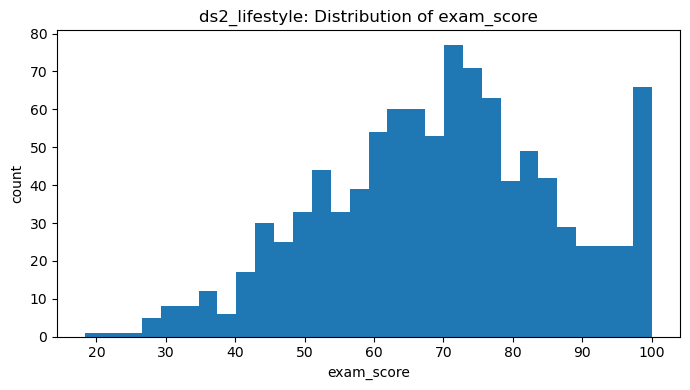

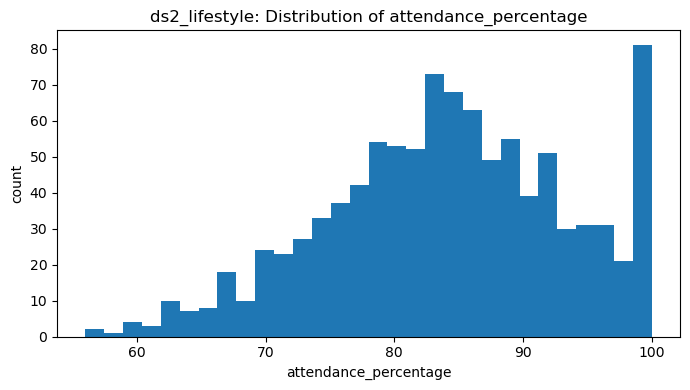

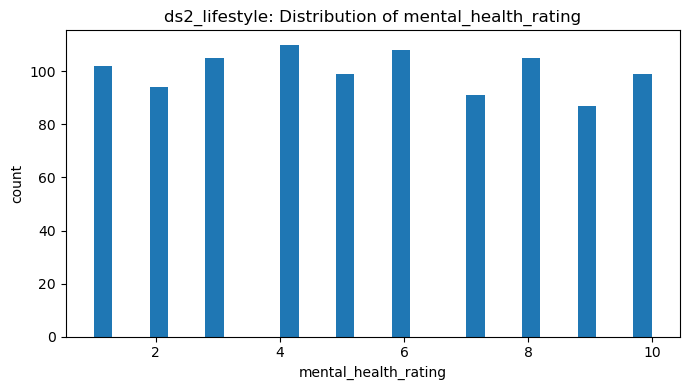

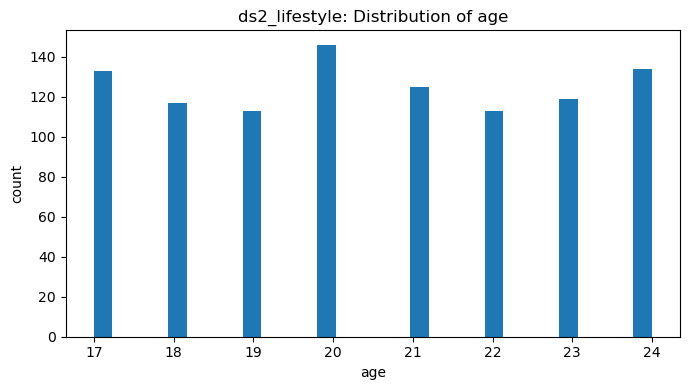

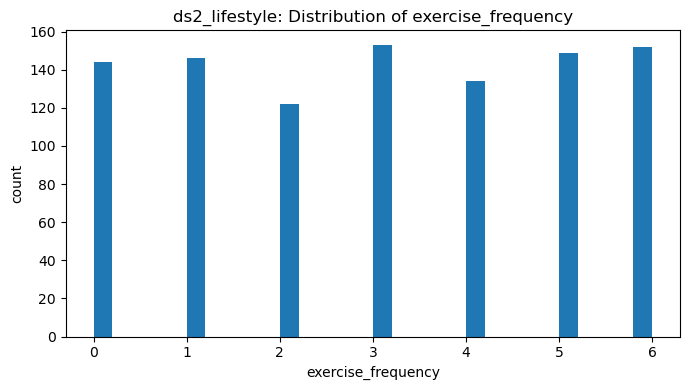

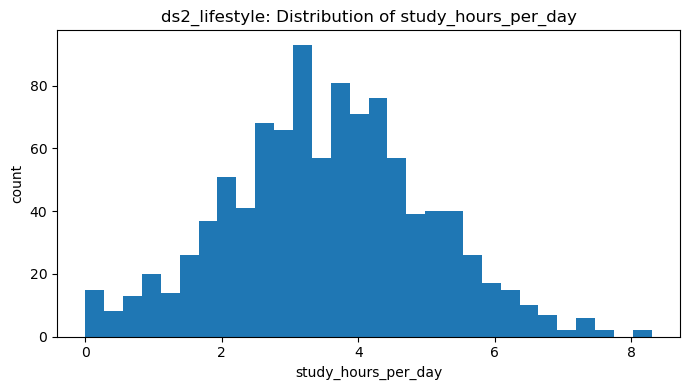


Plots: correlation heatmap (numeric columns)


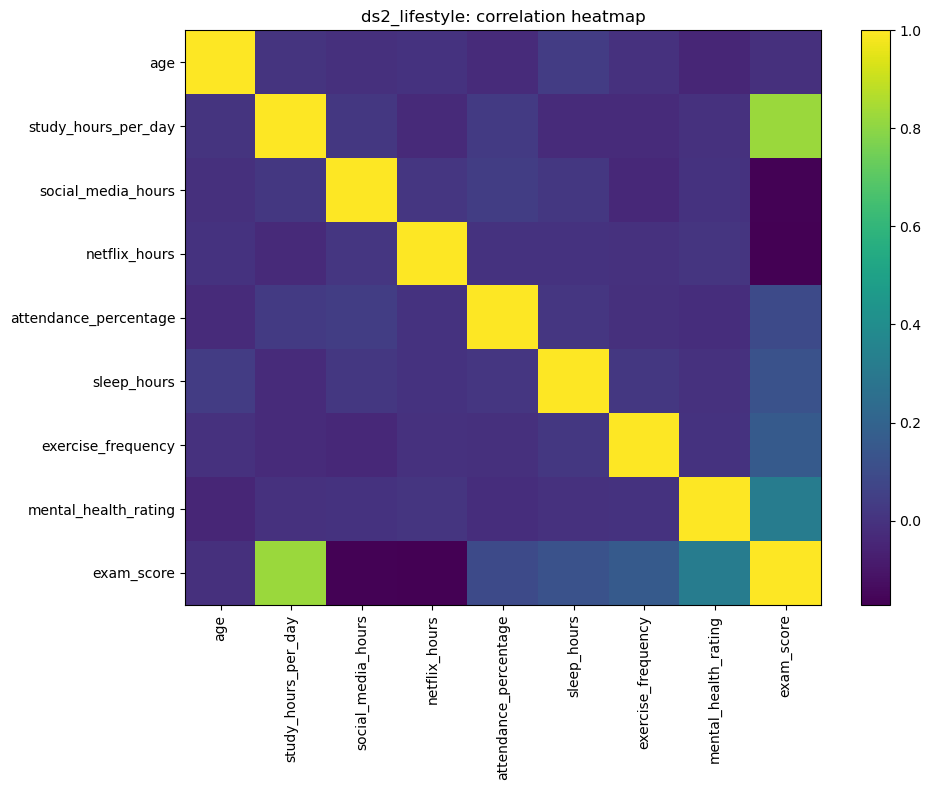


🎯 Target-focused profiling for ds2_lifestyle: 'exam_score'


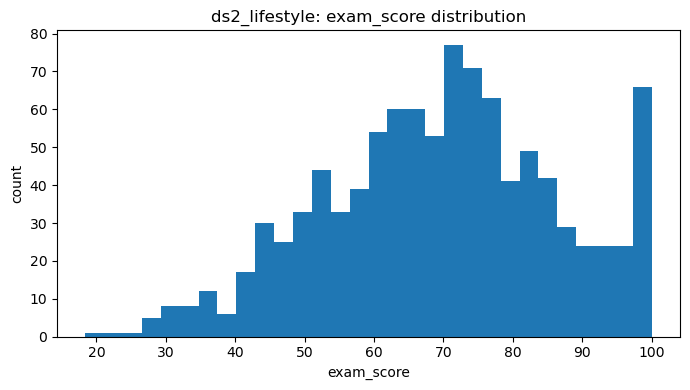


Mean exam_score by part_time_job:


part_time_job
No     69.836561
Yes    68.743256
Name: exam_score, dtype: float64


Mean exam_score by extracurricular_participation:


extracurricular_participation
Yes    69.623270
No     69.591349
Name: exam_score, dtype: float64


Mean exam_score by gender:


...


Column: ai_usage_purpose | unique_count=5


,ai_usage_purpose,pct
0,Exam Prep,17.10
1,NaN,16.83
2,Doubt Solving,16.78
3,Homework,16.65
4,Coding,16.44
5,Notes,16.21



Column: performance_category | unique_count=3


,performance_category,pct
0,Medium,58.81
1,Low,31.78
2,High,9.41



Plots: distributions (up to 6 numeric columns)


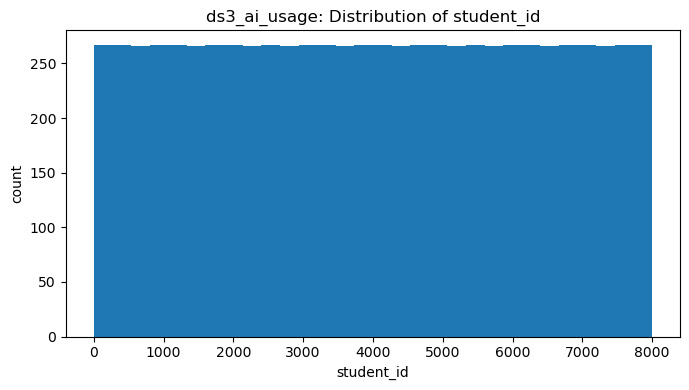

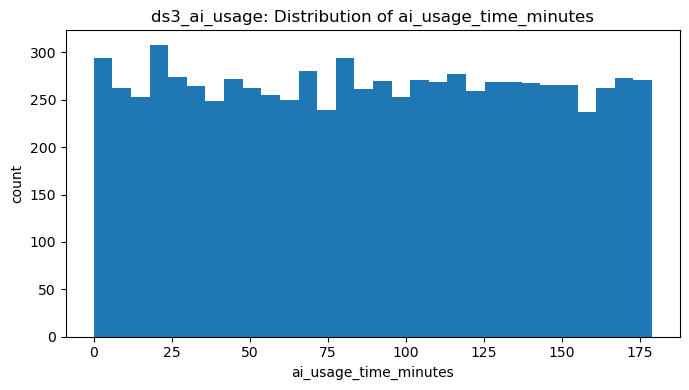

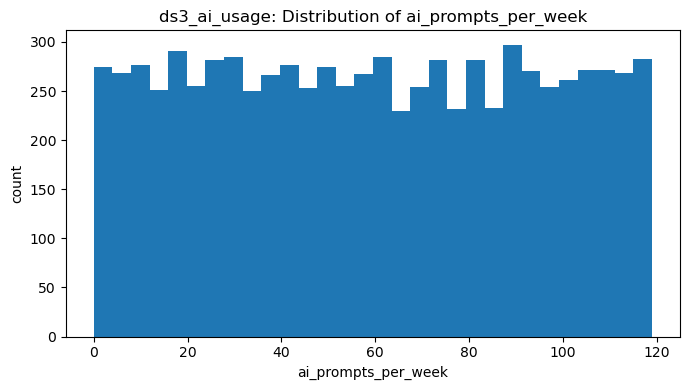

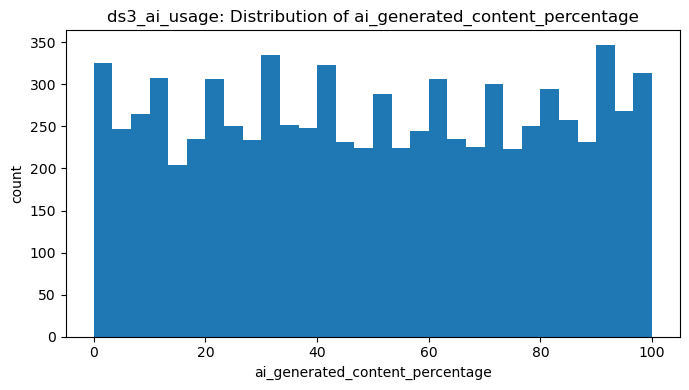

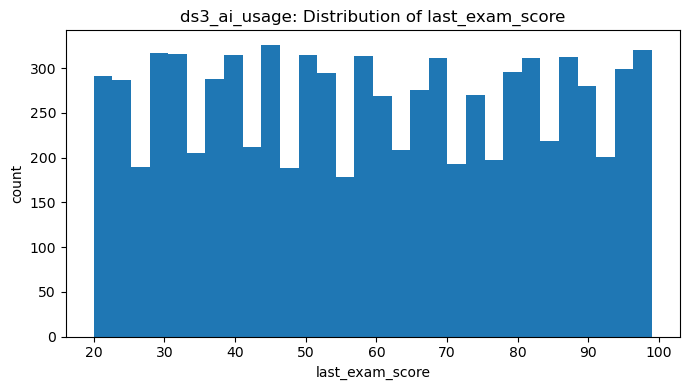

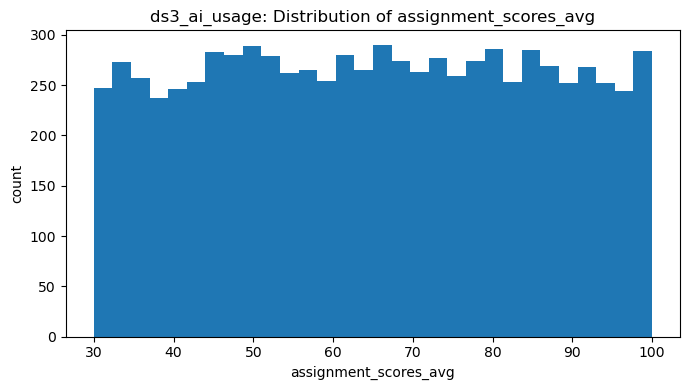


Plots: correlation heatmap (numeric columns)


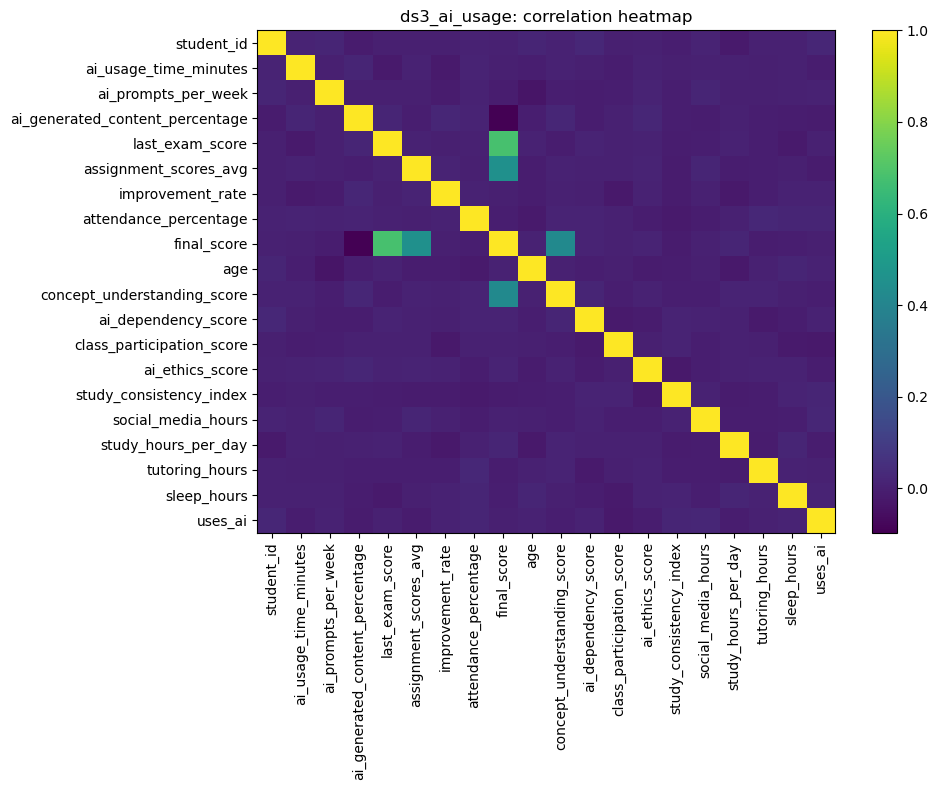


🎯 Target-focused profiling for ds3_ai_usage: 'final_score'


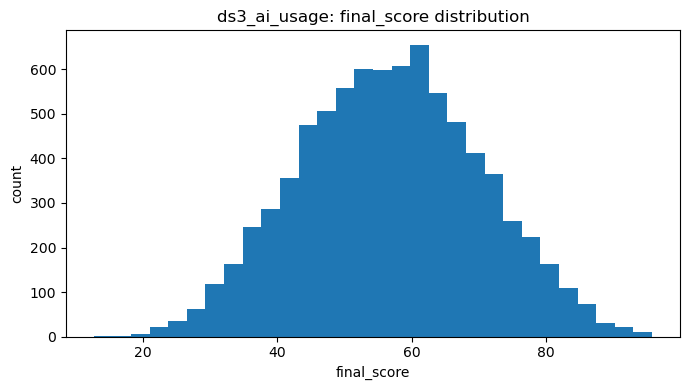


Mean final_score by gender:


gender
Male      56.846878
Female    56.840514
Other     55.939858
Name: final_score, dtype: float64


Mean final_score by performance_category:


performance_category
High      80.696547
Medium    61.240191
Low       41.540637
Name: final_score, dtype: float64


Mean final_score by ai_tools_used:


...


Column: affects_academic_performance | unique_count=2


,affects_academic_performance,pct
0,Yes,64.26
1,No,35.74



Column: relationship_status | unique_count=3


,relationship_status,pct
0,Single,54.47
1,In Relationship,40.99
2,Complicated,4.54



Plots: distributions (up to 6 numeric columns)


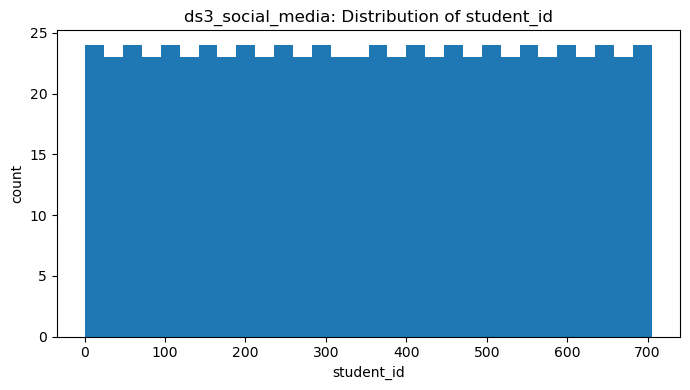

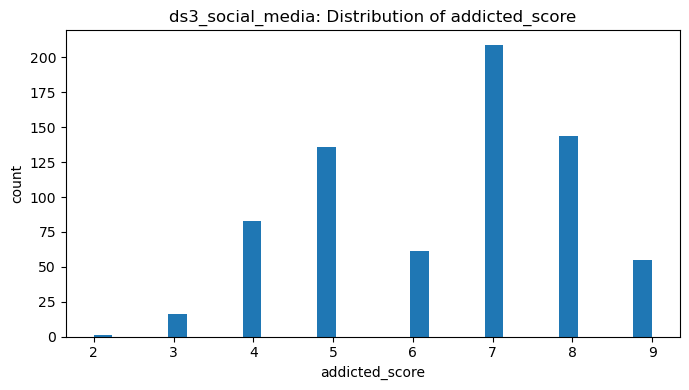

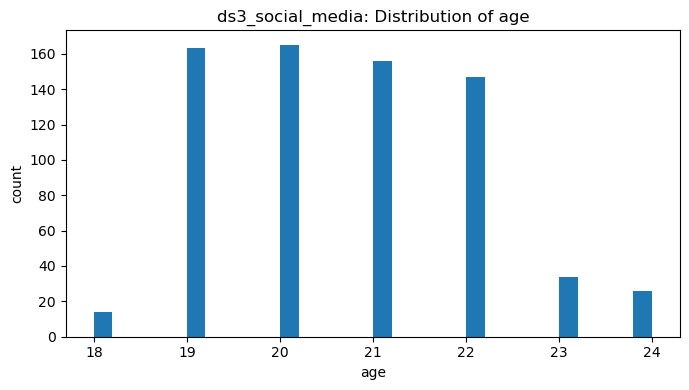

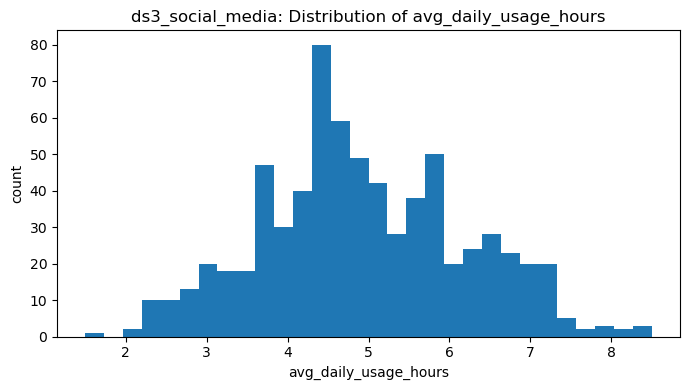

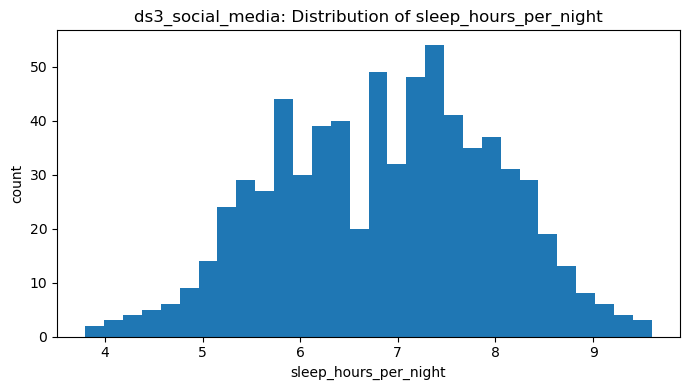

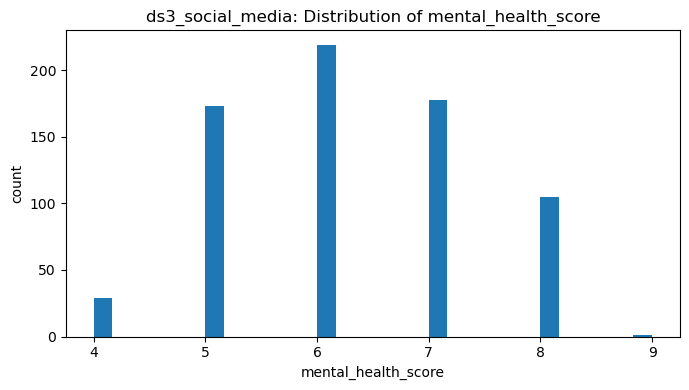


Plots: correlation heatmap (numeric columns)


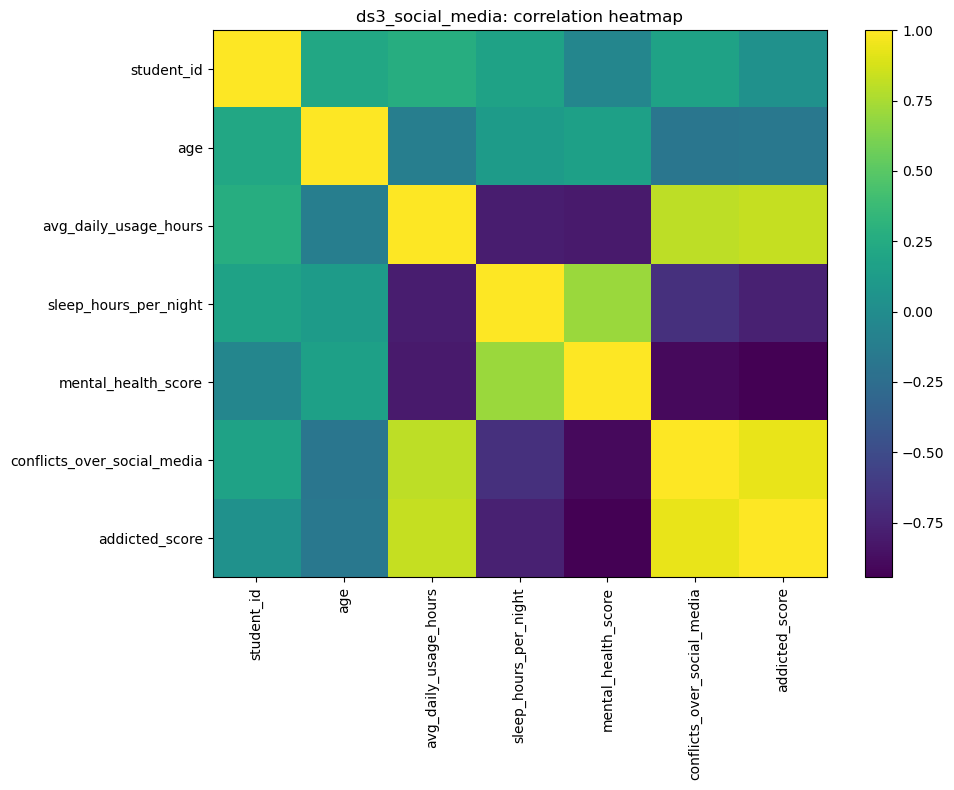


DATASET: ds4_digital_literacy
Overview: {'rows': 5010, 'cols': 1328, 'numeric_cols': 1019, 'categorical_cols': 309, 'datetime_cols': 0, 'memory_mb': 112.67, 'dtype_counts': {'float64': 998, 'object': 309, 'int64': 21}}

Head:


,cntryid,cntryid_e,seqid,age_r,gender_r,disp_cibq,disp_main,disp_mainwrc,a_n01_t,b_q01a,b_q01a_t,b_q01a3,b_q01a3_c,b_q01b,b_q01c1,b_q01c1_c,b_q01c1_t,b_q01c2,b_q01d,b_d01d,b_d01d_c,b_q02a,b_q02a_t1,b_q02a_t2,b_q02b,b_q02b_c,b_q02c,b_q03a,b_q03b,b_q03b_c,b_q03c1,b_q03c1_c,b_q03c2,b_q03d,b_d03d,b_d03d_c,b_q04a,b_q04b,b_q04b_c,b_q05a,b_q05b,b_q05c,b_q05c_t,b_q10a,b_q10b,b_q10c,b_q11,b_q12a,b_q12a_t,b_q12b,b_q12c,b_q12d,b_q12d_c,b_q12e,b_q12f,b_q12f_c,b_q12g,b_q12h,b_q12h_c,b_d12h,b_q13,b_q14a,b_q14b,b_q15a,b_q15b,b_q15c,b_q16,b_q17,b_q18a,b_q19a,b_q20a,b_q20b,b_q26a,b_q26a_t,b_q26b,c_q01a,c_q01b,c_q01c,c_q02a,c_q02b,c_q02c,c_q03_01,c_q03_02,c_q03_03,c_q03_04,c_q03_05,c_q03_06,c_q03_07,c_q03_08,c_q03_09,c_q03_10,c_s03,c_q04a,c_q04b,c_q04c,c_q04d,c_q04e,c_q04f,c_q04g,c_q04h,...,spfwt29,spfwt30,spfwt31,spfwt32,spfwt33,spfwt34,spfwt35,spfwt36,spfwt37,spfwt38,spfwt39,spfwt40,spfwt41,spfwt42,spfwt43,spfwt44,spfwt45,spfwt46,spfwt47,spfwt48,spfwt49,spfwt50,spfwt51,spfwt52,spfwt53,spfwt54,spfwt55,spfwt56,spfwt57,spfwt58,spfwt59,spfwt60,spfwt61,spfwt62,spfwt63,spfwt64,spfwt65,spfwt66,spfwt67,spfwt68,spfwt69,spfwt70,spfwt71,spfwt72,spfwt73,spfwt74,spfwt75,spfwt76,spfwt77,spfwt78,spfwt79,spfwt80,nfe12jr,nfe12njr,fnfe12jr,fnfaet12jr,fnfaet12njr,d_q18a_t,paidwork5,earnhr,earnhrdcl,earnmthalldcl,earnhrppp,earnhrbonus,earnhrbonusdcl,earnhrbonusppp,earnmth,earnmthppp,earnmthselfppp,earnmthbonus,earnmthall,earnmthallppp,earnmthbonusppp,earnflag,learnatwork,learnatwork_wle_ca,readytolearn,readytolearn_wle_ca,icthome,icthome_wle_ca,ictwork,ictwork_wle_ca,influence,influence_wle_ca,numhome,numhome_wle_ca,numwork,numwork_wle_ca,planning,planning_wle_ca,readhome,readhome_wle_ca,readwork,readwork_wle_ca,taskdisc,taskdisc_wle_ca,writhome,writhome_wle_ca,writwork,writwork_wle_ca
0,840,840,1,N,1,1,N,N,1.0,11.0,3.0,V,V,9,N,5.0,N,N,V,N,N,1.0,1.0,1.0,N,N,N,V,V,V,V,V,V,V,V,V,V,V,V,V,V,1,1,1,4,4,3,2.0,1.0,V,1.0,N,1,2.0,V,V,2.0,V,V,1.0,V,V,1,V,4,4,3,2,V,2,V,V,2.0,2.0,V,1.0,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,...,38913.486336,36901.106479,37208.599651,70369.323287,37269.632142,37128.921147,36955.910245,38053.346893,37178.670964,37206.132868,37368.436295,37293.558662,37132.864123,38124.194223,36566.689085,37457.671444,37648.049038,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,37474.518953,1.0,0.0,1.0,1.0,0.0,3.0,1.0,N,5,5,N,N,5,N,N,N,N,N,N,N,N,1,4.1625050356,5,2.361803,4.0,0.2560387589,1,V,V,0.9955969479,1,2.403889,4.0,1.10641917,1,1.049699449,1,1.414224,2.0,2.1419521124,3,1.4664265787,2,1.726160,2.0,1.2880792844,2
1,840,840,2,N,1,1,N,N,1.0,3.0,1.0,V,V,V,N,2.0,N,N,V,N,N,2.0,2.0,2.0,V,V,V,2,V,V,V,V,V,V,N,N,2,V,V,V,V,V,V,V,V,V,V,2.0,2.0,V,2.0,V,V,2.0,V,V,2.0,V,V,3.0,V,V,V,V,V,V,V,V,V,V,V,V,2.0,2.0,V,1.0,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,V,...,60228.043196,59927.829860,61884.394236,65918.197225,61423.379186,58742.450155,60544.748810,61494.576994,62393.103519,59293.484528,61555.370706,60518.875574,62202.733562,60026.432872,62599.661841,59913.196361,60297.531285,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,60473.209611,0.0,0.0,0.0,0.0,0.0,2.0,1.0,N,3,4,N,N,3,N,N,N,N,N,N,N,N,1,1.1786627737,1,1.945596,3.0,V,V,V,V,1.8848243997,3,0.558966,1.0,1.5468433373,2,3.7348138479,5


Missingness (top 15):


,missing_count,missing_pct
d_q16b_t,5010,100.00
random_cba_module1,5010,100.00
random_cba_module2,5010,100.00
random_cba_module1_stage1,5010,100.00
random_cba_module1_stage2,5010,100.00
random_cba_module2_stage1,5010,100.00
random_cba_module2_stage2,5010,100.00
random_pp,5010,100.00
reg_tl2,5010,100.00
zz5,5008,99.96



Duplicates: {'duplicate_rows': 0, 'id_like_duplicate_counts': {}, 'id_like_cols': []}

Numeric profile (top 15 by std):


...


Column: b_q01a3_c | unique_count=2


,b_q01a3_c,pct
0,V,97.56
1,NaN,2.14
2,N,0.30



Column: b_q01b | unique_count=12


,b_q01b,pct
0,N,27.45
1,4,13.97
2,V,12.61
3,8,9.32
4,5,7.90
5,2,6.07
6,3,6.05
7,6,5.71



Plots: distributions (up to 6 numeric columns)


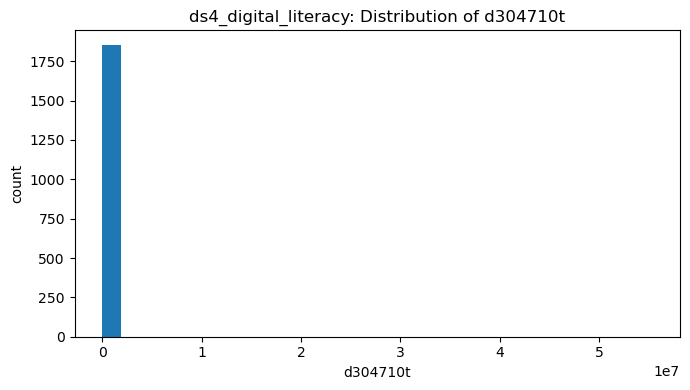

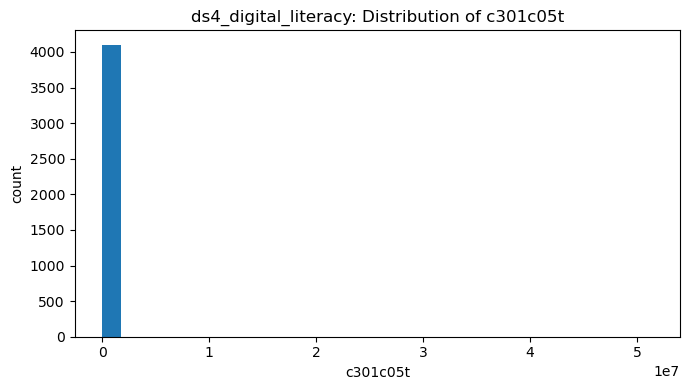

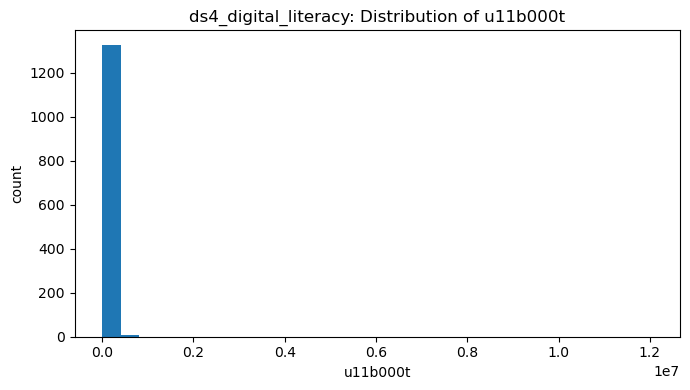

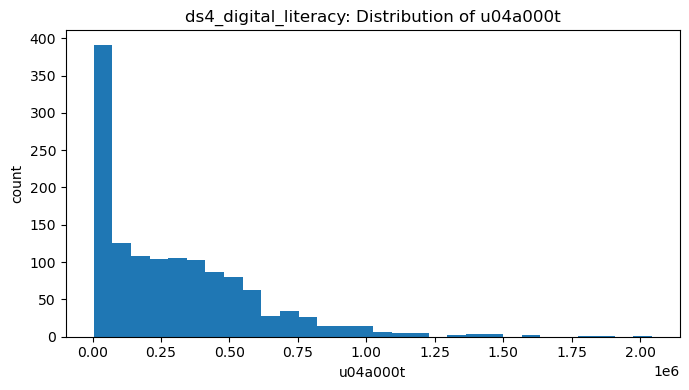

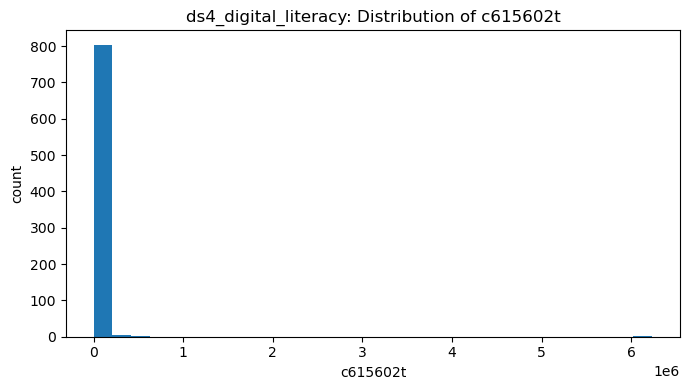

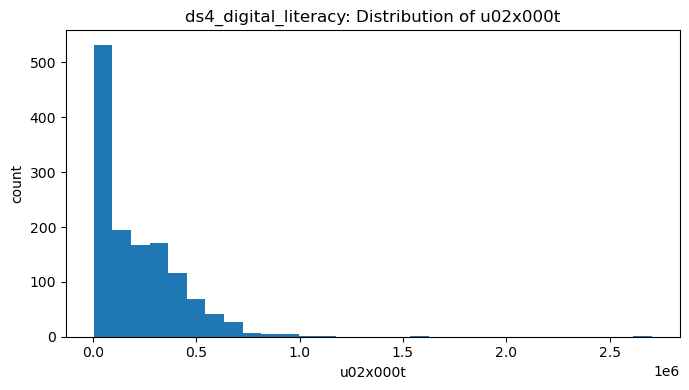


Plots: correlation heatmap (numeric columns)


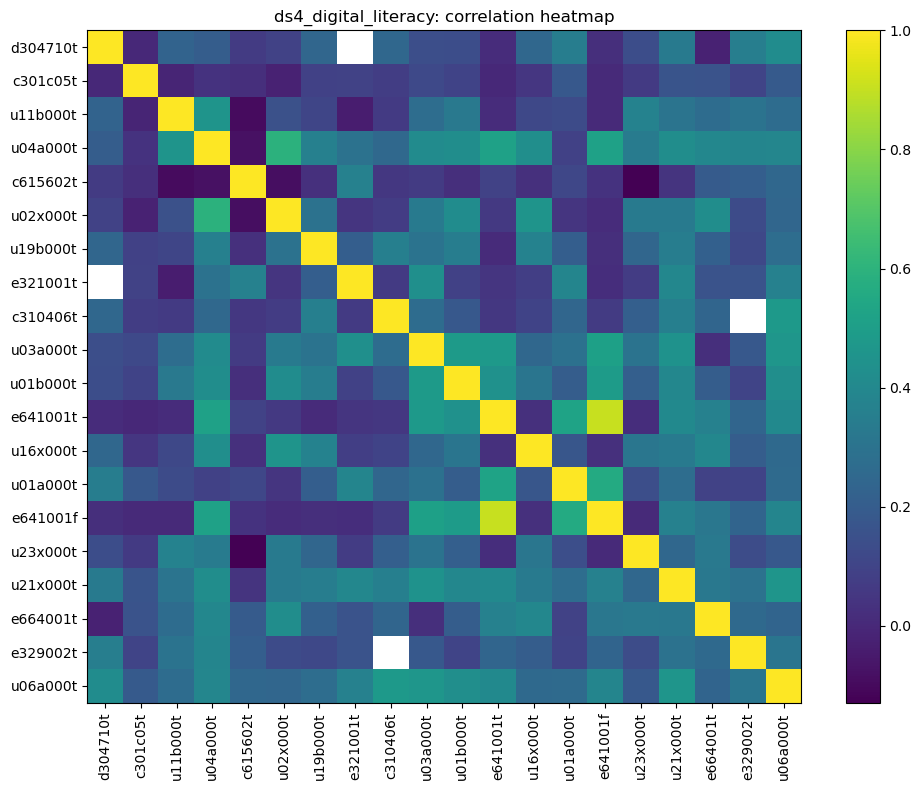


CROSS-DATASET COMPARISON: shared columns + schema differences

Shared columns across ALL 5 datasets (0):
[]

Pairwise shared column counts:


,dataset_a,dataset_b,shared_col_count
1,ds1_main,ds3_ai_usage,26
0,ds1_main,ds2_lifestyle,7
4,ds2_lifestyle,ds3_ai_usage,7
2,ds1_main,ds3_social_media,3
5,ds2_lifestyle,ds3_social_media,3
7,ds3_ai_usage,ds3_social_media,3
3,ds1_main,ds4_digital_literacy,0
6,ds2_lifestyle,ds4_digital_literacy,0
8,ds3_ai_usage,ds4_digital_literacy,0
9,ds3_social_media,ds4_digital_literacy,0



Dtype summary (first 50 rows):


,dataset,column,dtype
0,ds1_main,student_id,int64
1,ds1_main,age,int64
2,ds1_main,gender,object
3,ds1_main,grade_level,object
4,ds1_main,study_hours_per_day,float64
5,ds1_main,uses_ai,int64
6,ds1_main,ai_usage_time_minutes,int64
7,ds1_main,ai_tools_used,object
8,ds1_main,ai_usage_purpose,object
9,ds1_main,ai_dependency_score,int64


In [ ]:
# ============================================================
# Structured Dataset Profiling (Notebook Segment)
# For: ds1_main.csv, ds2_lifestyle.csv, ds3_ai-usage.csv,
#      ds3_social-media.csv, ds4_digital-literacy.csv
# ============================================================

import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = "datasets"  # change if needed

DATASETS = {
    "ds1_main": os.path.join(DATA_DIR, "ds1_main.csv"),
    "ds2_lifestyle": os.path.join(DATA_DIR, "ds2_lifestyle.csv"),
    "ds3_ai_usage": os.path.join(DATA_DIR, "ds3_ai-usage.csv"),
    "ds3_social_media": os.path.join(DATA_DIR, "ds3_social-media.csv"),
    "ds4_digital_literacy": os.path.join(DATA_DIR, "ds4_digital-literacy.csv"),
}

# -----------------------------
# Helpers
# -----------------------------
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Standardize column names to lowercase snake_case and strip whitespace."""
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^a-z0-9_]+", "", regex=True)
    )
    return df

def coerce_numeric_like(df: pd.DataFrame, min_numeric_ratio: float = 0.85) -> pd.DataFrame:
    """
    Convert object columns that are mostly numeric into numeric dtype.
    min_numeric_ratio: fraction of non-null values that must parse as numeric.
    """
    df = df.copy()
    for c in df.columns:
        if df[c].dtype == "object":
            s = df[c].astype(str).str.strip()
            # treat empty strings as NaN
            s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})
            parsed = pd.to_numeric(s, errors="coerce")
            non_null = s.notna().sum()
            if non_null > 0:
                ratio = parsed.notna().sum() / non_null
                if ratio >= min_numeric_ratio:
                    df[c] = parsed
    return df

def safe_read_csv(path: str) -> pd.DataFrame:
    """
    Robust CSV reader:
    - tries default comma
    - falls back to python engine if needed
    """
    # First attempt
    try:
        df = pd.read_csv(path)
        return df
    except Exception:
        pass

    # Second attempt with python engine
    try:
        df = pd.read_csv(path, engine="python")
        return df
    except Exception as e:
        raise RuntimeError(f"Failed to read {path}: {e}")

def basic_overview(df: pd.DataFrame) -> dict:
    """Return a dictionary of core dataset overview stats."""
    n_rows, n_cols = df.shape
    dtypes = df.dtypes.astype(str)
    type_counts = dtypes.value_counts().to_dict()
    mem_mb = df.memory_usage(deep=True).sum() / (1024**2)

    n_numeric = df.select_dtypes(include=[np.number]).shape[1]
    n_categorical = df.select_dtypes(include=["object", "category", "bool"]).shape[1]
    n_datetime = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).shape[1]

    return {
        "rows": n_rows,
        "cols": n_cols,
        "numeric_cols": n_numeric,
        "categorical_cols": n_categorical,
        "datetime_cols": n_datetime,
        "memory_mb": round(mem_mb, 2),
        "dtype_counts": type_counts,
    }

def missing_profile(df: pd.DataFrame) -> pd.DataFrame:
    """Missing value counts and percentages."""
    miss_cnt = df.isna().sum()
    miss_pct = (miss_cnt / len(df) * 100).round(2)
    out = pd.DataFrame({"missing_count": miss_cnt, "missing_pct": miss_pct})
    out = out.sort_values(["missing_pct", "missing_count"], ascending=False)
    return out

def duplicate_profile(df: pd.DataFrame) -> dict:
    """Duplicate rows and duplicate counts for likely ID columns."""
    dup_rows = int(df.duplicated().sum())

    # Heuristic: columns that look like IDs
    id_like = [c for c in df.columns if re.search(r"(?:^id$|_id$|^student_id$|^user_id$)", c)]
    id_dup_info = {}
    for c in id_like:
        if c in df.columns:
            # Only meaningful if not all missing
            non_null = df[c].notna().sum()
            if non_null > 0:
                id_dup_info[c] = int(df[c].duplicated().sum())
    return {"duplicate_rows": dup_rows, "id_like_duplicate_counts": id_dup_info, "id_like_cols": id_like}

def numeric_profile(df: pd.DataFrame) -> pd.DataFrame:
    """Descriptive stats for numeric columns + skewness."""
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] == 0:
        return pd.DataFrame()
    desc = num.describe().T
    desc["skew"] = num.skew(numeric_only=True)
    desc["kurtosis"] = num.kurtosis(numeric_only=True)
    return desc.sort_values("std", ascending=False)

def categorical_profile(df: pd.DataFrame, top_k: int = 10) -> dict:
    """
    For each categorical column, show:
    - unique count
    - top values (%)
    """
    cat = df.select_dtypes(include=["object", "category", "bool"])
    profiles = {}
    for c in cat.columns:
        vc = df[c].astype("object").value_counts(dropna=False)
        total = vc.sum()
        top = (vc.head(top_k) / total * 100).round(2)
        profiles[c] = {
            "unique_count": int(df[c].nunique(dropna=True)),
            "top_values_pct": top.to_frame("pct").reset_index().rename(columns={"index": c}),
        }
    return profiles

def correlation_plot(df: pd.DataFrame, title: str = "", max_cols: int = 20):
    """
    Correlation heatmap for numeric columns.
    Limits to max_cols to keep plots readable.
    """
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] < 2:
        print("Not enough numeric columns for correlation plot.")
        return

    # If too many numeric columns, pick those with highest variance (std)
    if num.shape[1] > max_cols:
        stds = num.std(numeric_only=True).sort_values(ascending=False)
        keep = stds.head(max_cols).index
        num = num[keep]

    corr = num.corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title(title or "Correlation heatmap")
    plt.tight_layout()
    plt.show()

def distribution_plots(df: pd.DataFrame, dataset_name: str, max_plots: int = 6):
    """
    Plot distributions for key numeric columns.
    - Picks up to max_plots numeric columns with highest variance
    """
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] == 0:
        print("No numeric columns to plot.")
        return

    stds = num.std(numeric_only=True).sort_values(ascending=False)
    cols = list(stds.head(max_plots).index)

    for c in cols:
        plt.figure(figsize=(7, 4))
        plt.hist(num[c].dropna(), bins=30)
        plt.title(f"{dataset_name}: Distribution of {c}")
        plt.xlabel(c)
        plt.ylabel("count")
        plt.tight_layout()
        plt.show()

def target_focus(df: pd.DataFrame, dataset_name: str, target_candidates=("exam_score", "final_score", "score")):
    """
    If a likely target variable exists, show extra profiling:
    - distribution
    - group means by key categoricals (if any)
    """
    target = None
    for t in target_candidates:
        if t in df.columns:
            target = t
            break
    if target is None:
        return

    print(f"\n🎯 Target-focused profiling for {dataset_name}: '{target}'")

    # Distribution
    plt.figure(figsize=(7, 4))
    plt.hist(df[target].dropna(), bins=30)
    plt.title(f"{dataset_name}: {target} distribution")
    plt.xlabel(target)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    # Group means for a few categoricals (top 3 by cardinality under threshold)
    cats = df.select_dtypes(include=["object", "category", "bool"])
    if cats.shape[1] == 0:
        return

    # Pick columns with reasonable cardinality
    good_cats = []
    for c in cats.columns:
        nuniq = df[c].nunique(dropna=True)
        if 2 <= nuniq <= 8:
            good_cats.append((c, nuniq))
    good_cats = sorted(good_cats, key=lambda x: x[1])[:3]

    for c, _ in good_cats:
        grp = df.groupby(c)[target].mean().sort_values(ascending=False)
        print(f"\nMean {target} by {c}:")
        display(grp)

# -----------------------------
# Main profiling runner
# -----------------------------s
def profile_dataset(df: pd.DataFrame, name: str):
    print("\n" + "=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)

    # Overview
    ov = basic_overview(df)
    print("Overview:", ov)

    # Sample rows
    print("\nHead:")
    display(df.head(5))

    # Missing values
    miss = missing_profile(df)
    print("\nMissingness (top 15):")
    display(miss.head(15))

    # Duplicates
    dup = duplicate_profile(df)
    print("\nDuplicates:", dup)

    # Numeric profile
    num_prof = numeric_profile(df)
    if not num_prof.empty:
        print("\nNumeric profile (top 15 by std):")
        display(num_prof.head(15))
    else:
        print("\nNo numeric columns found for numeric profiling.")

    # Categorical profile (top values)
    cat_prof = categorical_profile(df, top_k=8)
    if len(cat_prof) > 0:
        print("\nCategorical profile (showing up to 6 columns):")
        shown = 0
        for c, info in cat_prof.items():
            print(f"\nColumn: {c} | unique_count={info['unique_count']}")
            display(info["top_values_pct"])
            shown += 1
            if shown >= 6:
                break
    else:
        print("\nNo categorical columns found for categorical profiling.")

    # Plots
    print("\nPlots: distributions (up to 6 numeric columns)")
    distribution_plots(df, dataset_name=name, max_plots=6)

    print("\nPlots: correlation heatmap (numeric columns)")
    correlation_plot(df, title=f"{name}: correlation heatmap", max_cols=20)

    # Target-focused profiling (if any)
    target_focus(df, dataset_name=name)

# ============================================================
# 1) Load all datasets
# ============================================================
dfs = {}
for name, path in DATASETS.items():
    print(f"Loading {name} from {path} ...")
    df = safe_read_csv(path)

    # Standardize columns & basic coercions
    df = standardize_columns(df)
    df = coerce_numeric_like(df, min_numeric_ratio=0.85)

    # Keep a copy
    dfs[name] = df

print("\nLoaded datasets:", list(dfs.keys()))

# ============================================================
# 2) Profile each dataset (Notebook-style)
# ============================================================
for name, df in dfs.items():
    profile_dataset(df, name)

# ============================================================
# 3) Cross-dataset schema comparison (optional but strong)
# ============================================================
print("\n" + "=" * 80)
print("CROSS-DATASET COMPARISON: shared columns + schema differences")
print("=" * 80)

all_cols = {name: set(df.columns) for name, df in dfs.items()}
shared = set.intersection(*all_cols.values())
print(f"\nShared columns across ALL 5 datasets ({len(shared)}):")
print(sorted(shared))

# Pairwise overlaps
pairs = []
names = list(dfs.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        a, b = names[i], names[j]
        inter = all_cols[a].intersection(all_cols[b])
        pairs.append((a, b, len(inter)))

pair_df = pd.DataFrame(pairs, columns=["dataset_a", "dataset_b", "shared_col_count"]).sort_values("shared_col_count", ascending=False)
print("\nPairwise shared column counts:")
display(pair_df)

# Dtype summary per dataset
dtype_summaries = []
for name, df in dfs.items():
    dtype_summaries.append(
        pd.DataFrame({"dataset": name, "column": df.columns, "dtype": df.dtypes.astype(str).values})
    )
dtype_summaries = pd.concat(dtype_summaries, ignore_index=True)
print("\nDtype summary (first 50 rows):")
display(dtype_summaries.head(50))

In [52]:
ds1 = pd.read_csv("datasets/ds1_main.csv")

list(ds1.columns)

['student_id',
 'age',
 'gender',
 'grade_level',
 'study_hours_per_day',
 'uses_ai',
 'ai_usage_time_minutes',
 'ai_tools_used',
 'ai_usage_purpose',
 'ai_dependency_score',
 'ai_generated_content_percentage',
 'ai_prompts_per_week',
 'ai_ethics_score',
 'last_exam_score',
 'assignment_scores_avg',
 'attendance_percentage',
 'concept_understanding_score',
 'study_consistency_index',
 'improvement_rate',
 'sleep_hours',
 'social_media_hours',
 'tutoring_hours',
 'class_participation_score',
 'final_score',
 'passed',
 'performance_category']

In [53]:
ds2 = pd.read_csv("datasets/ds2_lifestyle.csv")

list(ds2.columns)

['student_id',
 'age',
 'gender',
 'study_hours_per_day',
 'social_media_hours',
 'netflix_hours',
 'part_time_job',
 'attendance_percentage',
 'sleep_hours',
 'diet_quality',
 'exercise_frequency',
 'parental_education_level',
 'internet_quality',
 'mental_health_rating',
 'extracurricular_participation',
 'exam_score']

In [54]:
ds3 = pd.read_csv("datasets/ds3_social-media.csv")

list(ds3.columns)

['Student_ID',
 'Age',
 'Gender',
 'Academic_Level',
 'Country',
 'Avg_Daily_Usage_Hours',
 'Most_Used_Platform',
 'Affects_Academic_Performance',
 'Sleep_Hours_Per_Night',
 'Mental_Health_Score',
 'Relationship_Status',
 'Conflicts_Over_Social_Media',
 'Addicted_Score']

In [56]:
ds4 = pd.read_csv("datasets/ds4_digital-literacy.csv")

list(ds4.columns)

/var/folders/xp/_lnkq25j6p1bkmtdh222qyx00000gn/T/ipykernel_3835/1892110962.py:1: DtypeWarning: Columns (8,9,10,21,22,23,75,104,106,107,108,117,118,240,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,281,282,283,284,285,286,287,288,289,290,291,292,294,296,299,308,309,315,316,317,324,393,395,396,397,398,409,410,411,414,421,422,426,427,437,441,445,449,453,457,461,465,469,473,477,485,497,501,505,509,513,517,521,529,533,537,541,545,557,561,565,569,573,577,581,585,597,605,609,613,617,641,645,653,657,661,665,669,673,677,681,685,689,693,697,701,705,709,713,717,721,725,729,733,737,741,745,749,753,757,761,765,769,773,777,781,785,789,793,797,801,805,809,813,821,829,833,837,841,845,849,896,898,899,900,901,903,904,907,908,909,917,918,919,920,921,922,923,924,925,926,927,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,958,960,962,964,966,968,970,972,974,976,978,980,982,984,986,988,990,992,994,996,998,1000,1002,1004,1006,1008,1010,101

['CNTRYID',
 'CNTRYID_E',
 'SEQID',
 'AGE_R',
 'GENDER_R',
 'DISP_CIBQ',
 'DISP_MAIN',
 'DISP_MAINWRC',
 'A_N01_T',
 'B_Q01a',
 'B_Q01a_T',
 'B_Q01a3',
 'B_Q01a3_C',
 'B_Q01b',
 'B_Q01c1',
 'B_Q01c1_C',
 'B_Q01c1_T',
 'B_Q01c2',
 'B_Q01d',
 'B_D01d',
 'B_D01d_C',
 'B_Q02a',
 'B_Q02a_T1',
 'B_Q02a_T2',
 'B_Q02b',
 'B_Q02b_C',
 'B_Q02c',
 'B_Q03a',
 'B_Q03b',
 'B_Q03b_C',
 'B_Q03c1',
 'B_Q03c1_C',
 'B_Q03c2',
 'B_Q03d',
 'B_D03d',
 'B_D03d_C',
 'B_Q04a',
 'B_Q04b',
 'B_Q04b_C',
 'B_Q05a',
 'B_Q05b',
 'B_Q05c',
 'B_Q05c_T',
 'B_Q10a',
 'B_Q10b',
 'B_Q10c',
 'B_Q11',
 'B_Q12a',
 'B_Q12a_T',
 'B_Q12b',
 'B_Q12c',
 'B_Q12d',
 'B_Q12d_C',
 'B_Q12e',
 'B_Q12f',
 'B_Q12f_C',
 'B_Q12g',
 'B_Q12h',
 'B_Q12h_C',
 'B_D12h',
 'B_Q13',
 'B_Q14a',
 'B_Q14b',
 'B_Q15a',
 'B_Q15b',
 'B_Q15c',
 'B_Q16',
 'B_Q17',
 'B_Q18a',
 'B_Q19a',
 'B_Q20a',
 'B_Q20b',
 'B_Q26a',
 'B_Q26a_T',
 'B_Q26b',
 'C_Q01a',
 'C_Q01b',
 'C_Q01c',
 'C_Q02a',
 'C_Q02b',
 'C_Q02c',
 'C_Q03_01',
 'C_Q03_02',
 'C_Q03_03',
 'C_Q03_04